题目描述：
已知一个四层前馈神经网络（全连接），结构如下：
输入层：6 个神经元
隐藏层1：8 个神经元，激活函数为 ReLU，带 BatchNorm1d
隐藏层2：8 个神经元，激活函数为 ReLU，带 BatchNorm1d，与隐藏层1有残差连接
隐藏层3：4 个神经元，激活函数为 GELU
输出层：4 个神经元（多分类），无激活（CrossEntropyLoss 自动加 softmax）
参数初始化（均需 requires_grad=True）：

W1 = shape [8, 6]，b1 = [8]

W2 = shape [8, 8]，b2 = [8]

W3 = shape [4, 8]，b3 = [4]

W_out = shape [4, 4]，b_out = [4]

BatchNorm1d 层参数初始化为默认
输入特征与标签（Batch）：
X = [[1.0, -1.0, 2.0, 0.5, 0.0, 1.0], [0.5, 0.0, -1.5, 1.0, 2.0, -0.5], [2.0, 1.0, 0.0, -1.0, 1.5, 0.5], [0.0, 0.0, 1.0, 1.0, -1.0, 2.0]] # shape = [4, 6]

y = [2, 0, 1, 3] # shape = [4]，分别对应四个样本的类别

正则化与优化要求：
L1正则化：损失函数中加入所有权重参数（W1、W2、W3、W_out）的L1正则项，正则系数λ1=0.01
L2正则化：损失函数中加入所有权重参数（W1、W2、W3、W_out）的L2正则项，正则系数λ2=0.01
动态学习率：如果当前 epoch 损失高于上一个 epoch，则学习率减半，否则保持不变，初始 lr=0.1
残差连接要求：
隐藏层2的输出为：H2 = ReLU(BN2(H1 @ W2^T + b2) + H1) # H1和H2 shape一致
计算要求：
前向传播
计算隐藏层1输出 H1 = ReLU(BN1(X @ W1^T + b1))
计算隐藏层2输出 H2 = ReLU(BN2(H1 @ W2^T + b2) + H1) # 残差连接
计算隐藏层3输出 H3 = GELU(H2 @ W3^T + b3)
计算输出层 Z = H3 @ W_out^T + b_out
用 nn.CrossEntropyLoss() 计算损失，并加上L1、L2正则项
反向传播
loss.backward()，获得各参数的梯度
参数更新
用当前学习率手动SGD更新一次参数（不使用优化器）
若损失未下降，学习率减半
输出结果
打印 softmax 后的输出概率
打印损失值（含正则项）
打印每个参数的梯度
打印更新后的参数值
打印每个 epoch 的学习率变化

In [ ]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available else "cpu")

In [ ]:
def forward(w1, w2, w3, w_out, b1, b2, b3, b_out, x, bn1, bn2):
  z1 = x @ w1.T +b1

  h1 = torch.relu(bn1(z1))

  z2 = h1 @ w2.T +b2
  h2 = torch.relu(bn2(z2) + h1)

  z3 = h2 @ w3.T +b3
  h3 = nn.functional.gelu(z3)

  z_out = h3 @ w_out.T +b_out

  return z_out

epoch: 1 loss: 5.0123
epoch: 101 loss: 1.6994
epoch: 201 loss: 1.0955
epoch: 301 loss: 0.7175
epoch: 401 loss: 0.4818
epoch: 501 loss: 0.3954
epoch: 601 loss: 0.3689
epoch: 701 loss: 0.3537
the predication value is:
tensor([[1.5123e-02, 5.1628e-03, 9.7582e-01, 3.8932e-03],
        [9.0930e-01, 3.4848e-02, 4.1286e-02, 1.4564e-02],
        [1.6427e-02, 9.8081e-01, 8.0102e-04, 1.9580e-03],
        [1.4801e-02, 3.1164e-03, 4.1038e-03, 9.7798e-01]],
       grad_fn=<SoftmaxBackward0>)
the y_pred index is:
tensor(9)
the y_true index is:
tensor([2, 0, 1, 3])


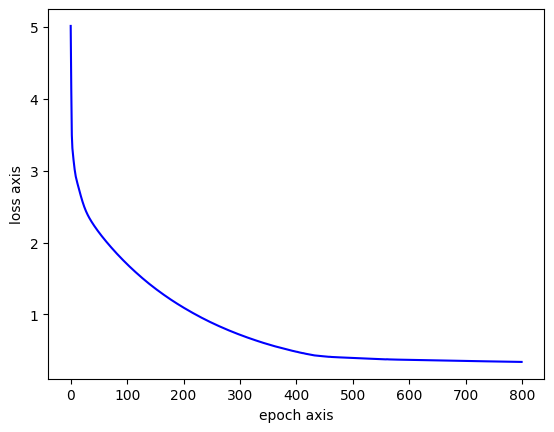

In [ ]:
#初始化
w1 = torch.randn(8,6, requires_grad=True)
b1 = torch.randn(8, requires_grad=True)

w2 = torch.randn(8,8, requires_grad=True)
b2 = torch.randn(8, requires_grad=True)

w3 = torch.randn(4,8, requires_grad=True)
b3 = torch.randn(4, requires_grad=True)

w_out = torch.randn(4,4, requires_grad=True)
b_out = torch.randn(4, requires_grad=True)

x = torch.tensor([[1.0, -1.0, 2.0, 0.5, 0.0, 1.0],
          [0.5, 0.0, -1.5, 1.0, 2.0, -0.5],
          [2.0, 1.0, 0.0, -1.0, 1.5, 0.5],
          [0.0, 0.0, 1.0, 1.0, -1.0, 2.0]])

y_true_index = torch.tensor([2, 0, 1, 3])

losses = []
epochs = 800

lr = 0.1
lambda1 = 0.01
lambda2 = 0.01
last_loss = None

bn1 = nn.BatchNorm1d(8)
bn2 = nn.BatchNorm1d(8)

criterion = nn.CrossEntropyLoss()

for epoch in range(epochs):
  z_out = forward(w1, w2, w3, w_out, b1, b2, b3, b_out, x, bn1, bn2)
  y_pred = torch.softmax(z_out, dim=1)

  l1 = (w1.abs().sum() + w2.abs().sum() + w3.abs().sum() + w_out.abs().sum())
  l2 = (w1.pow(2).sum() + w2.pow(2).sum() + w3.pow(2).sum() + w_out.pow(2).sum())

  loss = criterion(z_out, y_true_index) + lambda1*l1 + lambda2*l2
  losses.append(loss.item())

  loss.backward()

  with torch.no_grad():
    w1 -= lr * w1.grad
    w2 -= lr * w2.grad
    w3 -= lr * w3.grad
    b1 -= lr * b1.grad
    b2 -= lr * b2.grad
    b3 -= lr * b3.grad
    w_out -= lr * w_out.grad
    b_out -= lr * b_out.grad


  w1.grad.zero_()
  w2.grad.zero_()
  w3.grad.zero_()
  w_out.grad.zero_()

  b1.grad.zero_()
  b2.grad.zero_()
  b3.grad.zero_()
  b_out.grad.zero_()

  #动态学习率
  if last_loss is not None and loss.item() > last_loss:
    lr *=0.5

  last_loss = loss.item()

  if epoch%100 == 0:
    print(f"epoch: {epoch+1}",
    f"loss: {loss.item():.4f}")

with torch.no_grad():
  y_pred_index = torch.argmax(y_pred)

print("the predication value is:")
print(y_pred)

print("the y_pred index is:")
print(y_pred_index)

print("the y_true index is:")
print(y_true_index)

plt.plot(range(epochs), losses, "blue")
plt.xlabel("epoch axis")
plt.ylabel("loss axis")

plt.show()